# 020 — Training

Train UNet, ResUNet, Attention UNet, and EfficientNet UNet on the RGB → IR translation task.
Checkpoints are saved to `models/{arch}/best_model.keras`.
Logs are written to `logs/{arch}/` for TensorBoard.

In [1]:
import sys
from pathlib import Path

project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

In [2]:
import matplotlib.pyplot as plt
import tensorflow as tf

from scripts.config import settings
from scripts.dataset import build_dataset, grouped_train_val_test_split, load_image_pairs
from scripts.trainer import compile_model, get_callbacks, get_model
from scripts.visualization import plot_training_curves

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")
print(f"TensorFlow version: {tf.__version__}")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow version: 2.16.2


## 1. Build datasets

In [3]:
pairs = load_image_pairs(settings.IR_DIR, settings.RGB_DIR)
train_pairs, val_pairs, _ = grouped_train_val_test_split(
    pairs,
    train_ratio=settings.TRAIN_RATIO,
    val_ratio=settings.VAL_RATIO,
    seed=settings.SEED,
)

train_ds = build_dataset(
    train_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=True,
    shuffle=True,
    seed=settings.SEED,
)
val_ds = build_dataset(
    val_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=False,
    shuffle=False,
)

print(f"Train: {len(train_pairs)} patches ({len(train_ds)} batches)")
print(f"Val:   {len(val_pairs)} patches ({len(val_ds)} batches)")

2026-06-04 00:51:44.107440: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-06-04 00:51:44.107470: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-04 00:51:44.107479: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-06-04 00:51:44.107498: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-04 00:51:44.107511: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Train: 423 patches (53 batches)
Val:   110 patches (14 batches)


## 2. Loss functions

Two loss variants are used in this notebook:

| Architecture | Loss |
|---|---|
| UNet, ResUNet, Attention UNet | `combined_loss` — MAE + (1 − SSIM) |
| EfficientNet UNet | `combined_loss_advanced` — MAE + Laplacian pyramid + FFT |

The **Laplacian pyramid** loss decomposes prediction error into spatial frequency bands
and weights finer detail more heavily (geometric sequence: level 0 weight = `2^(N-1)`, halved each level).
The **FFT loss** penalises magnitude-spectrum errors uniformly across all frequencies,
preventing the model from sacrificing high-frequency accuracy to reduce low-frequency error.
Both terms target the frequency band where underdrawing strokes live.

The cell below visualises the pyramid decomposition and FFT spectra of one training sample.

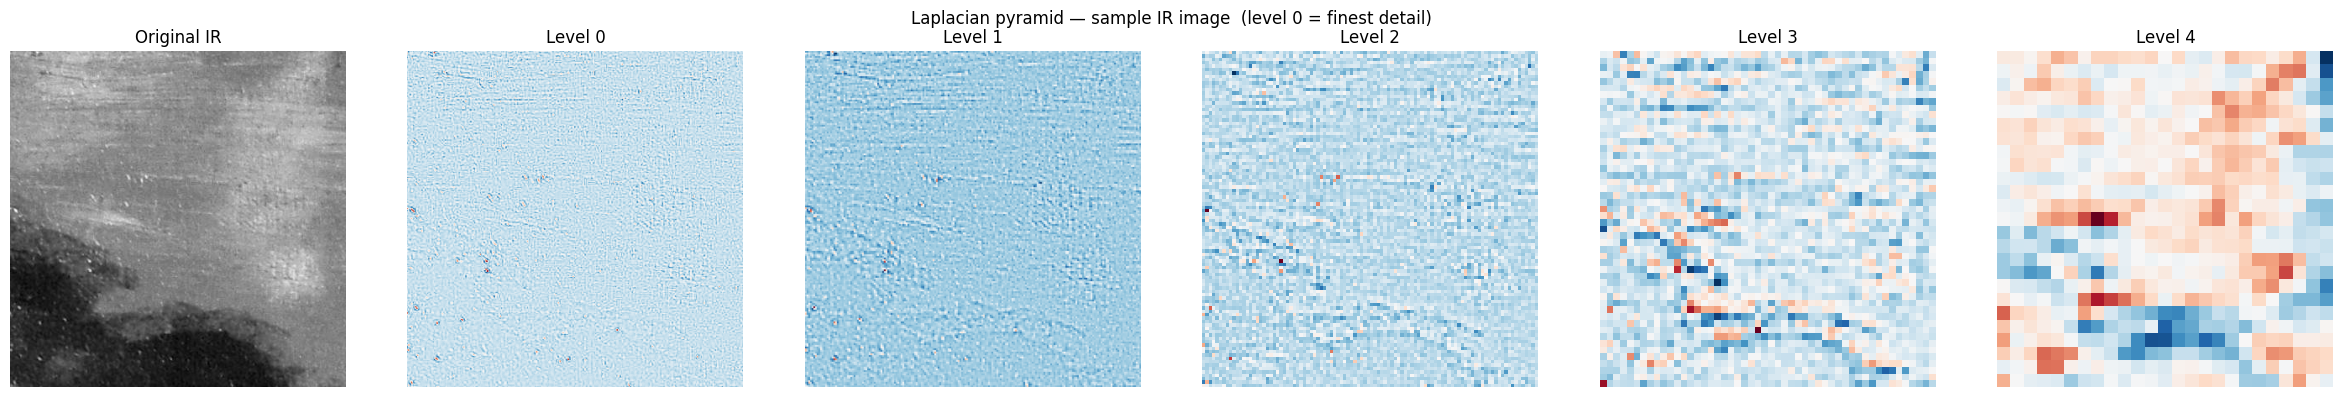

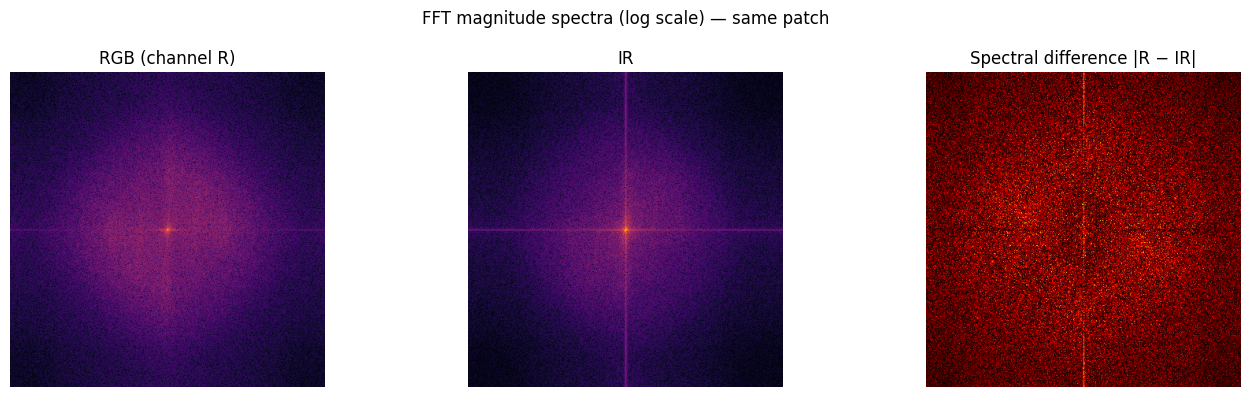

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image

# --- Laplacian pyramid on a sample IR image ---
ir_np = np.array(Image.open(train_pairs[0][1]).convert("L")).astype(np.float32) / 255.0
ir_t  = tf.constant(ir_np[np.newaxis, ..., np.newaxis])  # (1, H, W, 1)


def _lap_level(x: tf.Tensor) -> tuple:
    low    = tf.nn.avg_pool2d(x, ksize=2, strides=2, padding="VALID")
    up     = tf.image.resize(low, tf.shape(x)[1:3], method="bilinear")
    detail = (x - up)[0, ..., 0].numpy()
    return detail, low


LEVELS = 5
details, x = [], ir_t
for _ in range(LEVELS):
    d, x = _lap_level(x)
    details.append(d)

fig, axes = plt.subplots(1, LEVELS + 1, figsize=(4 * (LEVELS + 1), 4))
fig.suptitle("Laplacian pyramid — sample IR image  (level 0 = finest detail)")
axes[0].imshow(ir_np, cmap="gray"); axes[0].set_title("Original IR"); axes[0].axis("off")
for i, d in enumerate(details):
    d_disp = (d - d.min()) / (d.max() - d.min() + 1e-8)
    axes[i + 1].imshow(d_disp, cmap="RdBu_r")
    axes[i + 1].set_title(f"Level {i}")
    axes[i + 1].axis("off")
plt.tight_layout()
plt.show()

# --- FFT magnitude spectra ---
rgb_np  = np.array(Image.open(train_pairs[0][0]).convert("RGB")).astype(np.float32) / 255.0
log_rgb = np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(rgb_np[..., 0]))))
log_ir  = np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(ir_np))))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("FFT magnitude spectra (log scale) — same patch")
axes[0].imshow(log_rgb, cmap="inferno"); axes[0].set_title("RGB (channel R)"); axes[0].axis("off")
axes[1].imshow(log_ir,  cmap="inferno"); axes[1].set_title("IR"); axes[1].axis("off")
axes[2].imshow(np.abs(log_rgb - log_ir), cmap="hot")
axes[2].set_title("Spectral difference |R − IR|"); axes[2].axis("off")
plt.tight_layout()
plt.show()

## 3. Train all architectures

UNet, ResUNet, and Attention UNet use `combined_loss` (MAE + SSIM).
EfficientNet UNet uses `combined_loss_advanced` (MAE + Laplacian pyramid + FFT),
which better preserves the high-frequency detail that a pretrained encoder can reproduce.

Set `EPOCHS = 2` for a quick smoke test.

In [5]:
ARCH_CONFIGS = {
    "efficientnet_unet": {"advanced_loss": True},
}
EPOCHS = 3#settings.EPOCHS  # Change to 2 for a smoke test

histories: dict = {}

for arch, compile_kwargs in ARCH_CONFIGS.items():
    print(f"\n{'='*60}")
    print(f"  Architecture: {arch}")
    print(f"{'='*60}")

    model = get_model(arch)
    model = compile_model(
        model,
        lr=settings.LEARNING_RATE,
        loss_alpha=settings.LOSS_ALPHA,
        **compile_kwargs,
    )
    model.summary(line_length=80)

    callbacks = get_callbacks(
        arch,
        log_dir=settings.LOGS_DIR,
        model_dir=settings.MODELS_DIR,
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1,
    )
    histories[arch] = history.history

    best_val_loss = min(history.history["val_loss"])
    print(f"\nBest val_loss ({arch}): {best_val_loss:.4f}")


  Architecture: efficientnet_unet


Model: "efficientnet_unet"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1         │ (None, None,      │           0 │ -                  │
│ (InputLayer)          │ None, 3)          │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ multiply (Multiply)   │ (None, None,      │           0 │ input_layer_1[0][… │
│                       │ None, 3)          │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ efficientnet_b0_enco… │ [(None, None,     │   4,049,571 │ multiply[0][0]     │
│ (Functional)          │ None, 16), (None, │             │                    │
│                       │ None, None, 24),  │             │                    │
│                       │ (None, None,      │             │                    │
│                       │ None, 40), (None, │             │                    │
│                       │ None, None, 112), │             │                    │
│                       │ (None, None,      │             │                    │
│                       │ None, 1280)]      │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d (Conv2D)       │ (None, None,      │   2,949,120 │ efficientnet_b0_e… │
│                       │ None, 256)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization   │ (None, None,      │       1,024 │ conv2d[0][0]       │
│ (BatchNormalization)  │ None, 256)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu (ReLU)          │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None, 256)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_1 (Conv2D)     │ (None, None,      │     589,824 │ re_lu[0][0]        │
│                       │ None, 256)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_1 │ (None, None,      │       1,024 │ conv2d_1[0][0]     │
│ (BatchNormalization)  │ None, 256)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_1 (ReLU)        │ (None, None,      │           0 │ batch_normalizati… │
│                       │ None, 256)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_transpose      │ (None, None,      │     131,200 │ re_lu_1[0][0]      │
│ (Conv2DTranspose)     │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ __resize_to_match     │ (None, None,      │           0 │ conv2d_transpose[… │
│ (_ResizeToMatch)      │ None, 128)        │             │ efficientnet_b0_e… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ concatenate           │ (None, None,      │           0 │ __resize_to_match… │
│ (Concatenate)         │ None, 240)        │             │ efficientnet_b0_e… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_2 (Conv2D)     │ (None, None,      │     276,480 │ concatenate[0][0]  │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_2 │ (None, None,      │         512 │ conv2d_2[0][0]     │
│ (BatchNormalization)  │ None,

 Total params: 8,325,556 (31.76 MB)

 Trainable params: 4,273,937 (16.30 MB)

 Non-trainable params: 4,051,619 (15.46 MB)

Epoch 1/3


2026-06-04 00:51:56.465353: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - loss: 0.1310 - mae: 0.2134 - psnr: 12.2705 - ssim: 0.0514
Epoch 1: val_loss improved from None to 0.10260, saving model to /Users/marcomanduca/Desktop/projects/deep_layers/models/efficientnet_unet/best_model.keras

Epoch 1: finished saving model to /Users/marcomanduca/Desktop/projects/deep_layers/models/efficientnet_unet/best_model.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 49s 663ms/step - loss: 0.1212 - mae: 0.1976 - psnr: 12.9585 - ssim: 0.0652 - val_loss: 0.1026 - val_mae: 0.1839 - val_psnr: 14.2462 - val_ssim: 0.1976 - learning_rate: 1.0000e-04
Epoch 2/3
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - loss: 0.0930 - mae: 0.1524 - psnr: 15.1858 - ssim: 0.1315
Epoch 2: val_loss improved from 0.10260 to 0.08926, saving model to /Users/marcomanduca/Desktop/projects/deep_layers/models/efficientnet_unet/best_model.keras

Epoch 2: finished saving model to /Users/marcomanduca/Desktop/projects/deep_layers/models/efficientnet_unet/best_model.keras
53/53 ━━━━━━━━━

In [ ]:
ARCH_CONFIGS = {
    "unet":              {"advanced_loss": False},
    "resunet":           {"advanced_loss": False},
    "attention_unet":    {"advanced_loss": False},
    "efficientnet_unet": {"advanced_loss": True},
}
EPOCHS = 3#settings.EPOCHS  # Change to 2 for a smoke test

histories: dict = {}

for arch, compile_kwargs in ARCH_CONFIGS.items():
    print(f"\n{'='*60}")
    print(f"  Architecture: {arch}")
    print(f"{'='*60}")

    model = get_model(arch)
    model = compile_model(
        model,
        lr=settings.LEARNING_RATE,
        loss_alpha=settings.LOSS_ALPHA,
        **compile_kwargs,
    )
    model.summary(line_length=80)

    callbacks = get_callbacks(
        arch,
        log_dir=settings.LOGS_DIR,
        model_dir=settings.MODELS_DIR,
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1,
    )
    histories[arch] = history.history

    best_val_loss = min(history.history["val_loss"])
    print(f"\nBest val_loss ({arch}): {best_val_loss:.4f}")

## 3. Training curves

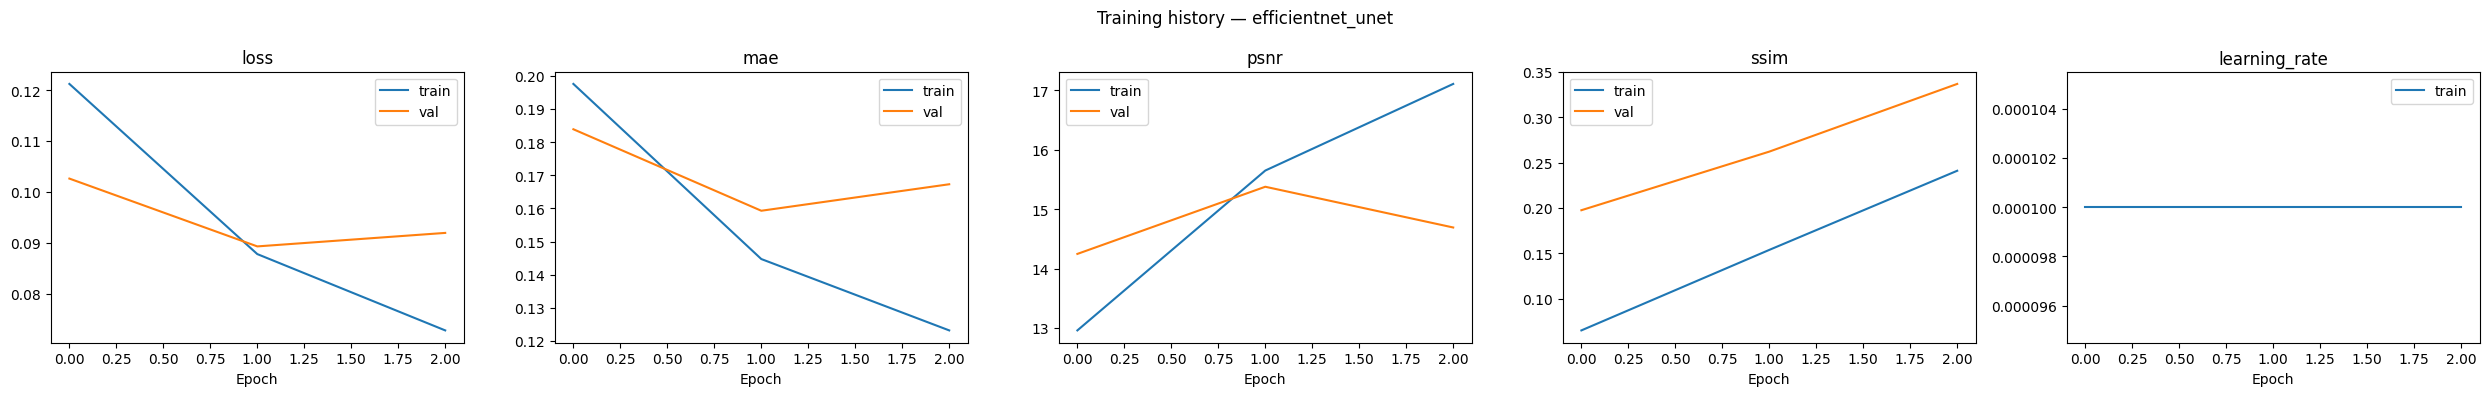

In [6]:
for arch, history in histories.items():
    fig = plot_training_curves(history, title=f"Training history — {arch}")
    plt.show()

## 4. Summary

Checkpoints saved to `models/{arch}/best_model.keras`.  
Run `tensorboard --logdir logs/` to inspect curves interactively.

> **Note:** `efficientnet_unet` downloads EfficientNetB0 ImageNet weights on first use.
> Subsequent runs use the local Keras cache.

In [7]:
for arch in ARCH_CONFIGS:
    ckpt = settings.MODELS_DIR / arch / "best_model.keras"
    status = "found" if ckpt.exists() else "MISSING"
    print(f"{arch:<25}: {status}  ({ckpt})")

efficientnet_unet        : found  (/Users/marcomanduca/Desktop/projects/deep_layers/models/efficientnet_unet/best_model.keras)
